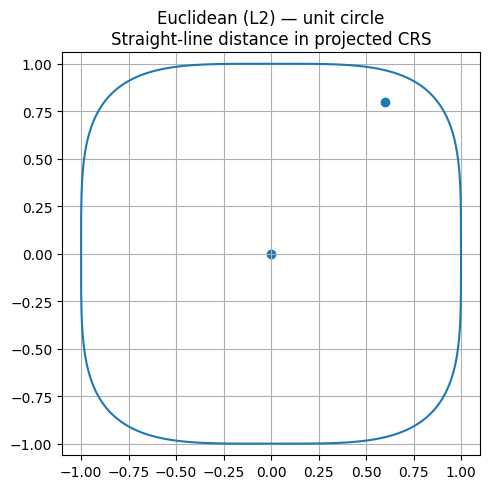

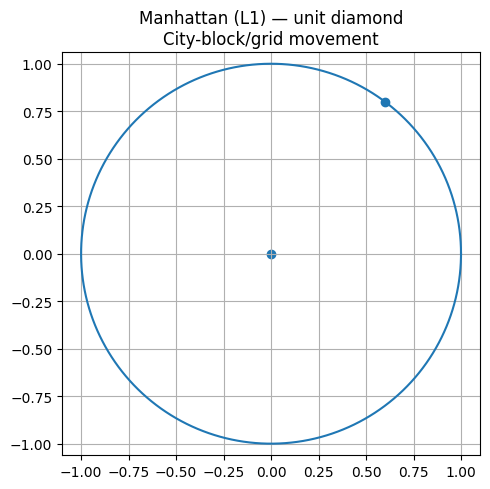

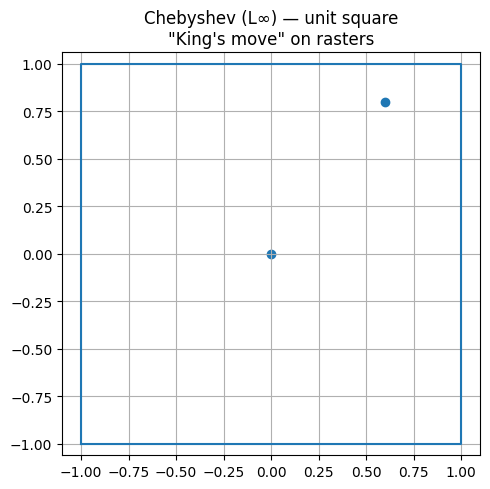

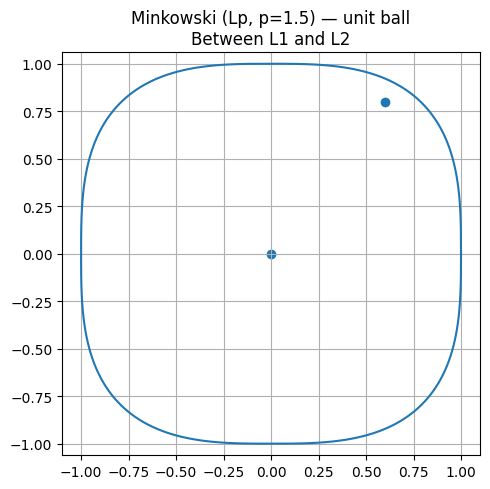

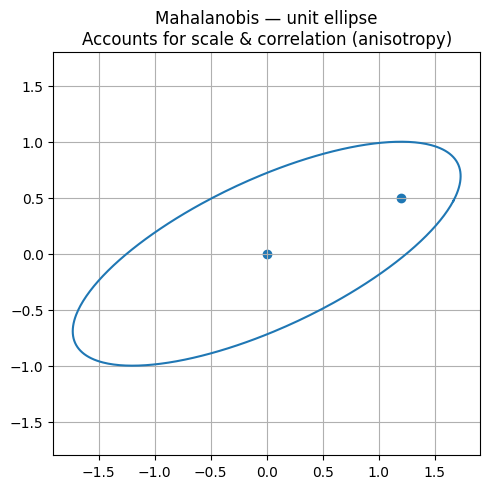

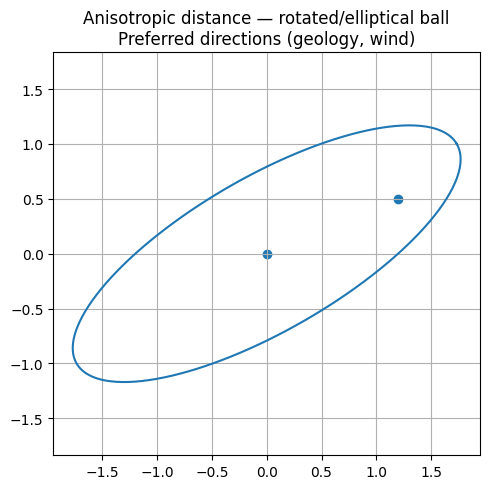

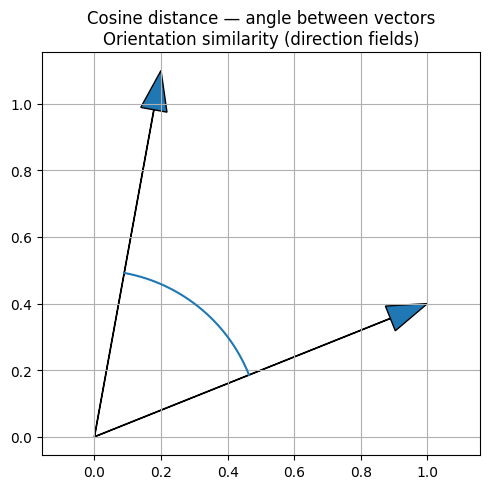

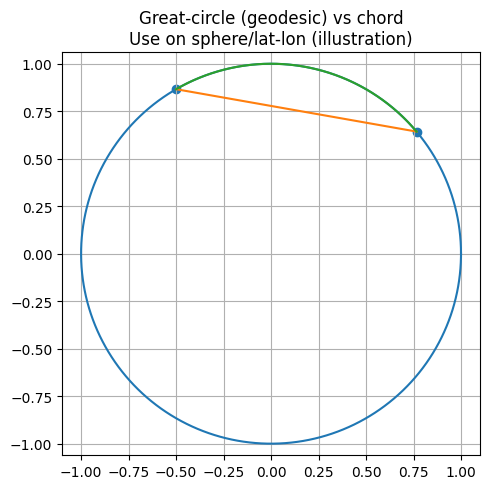

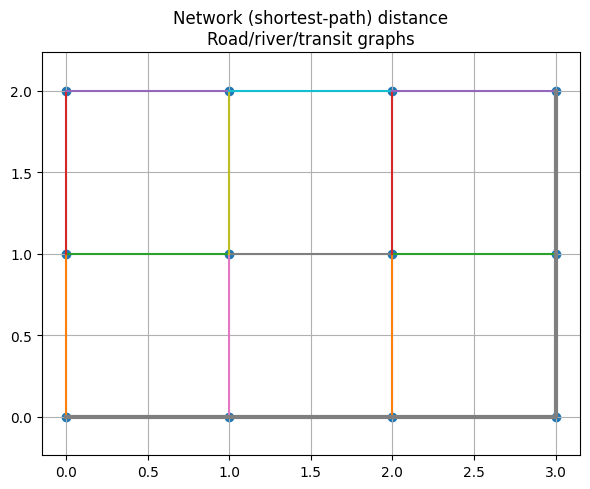

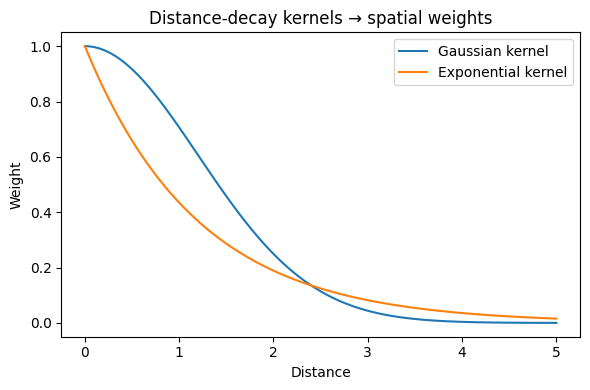

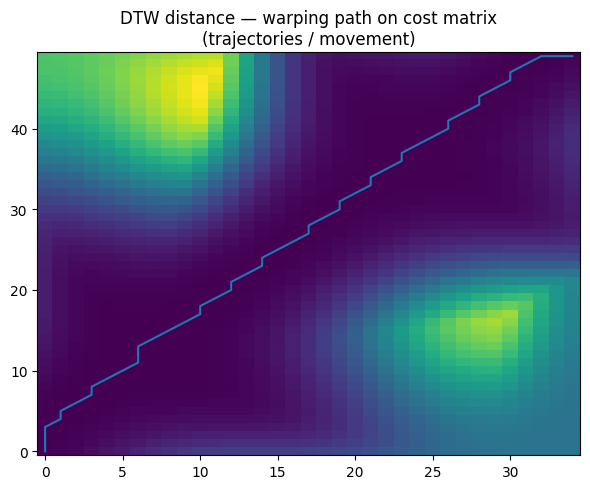

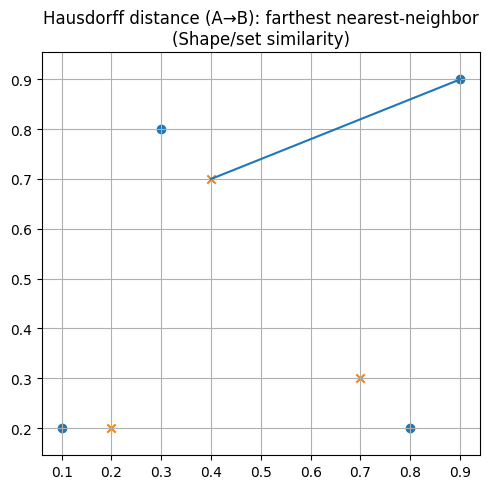

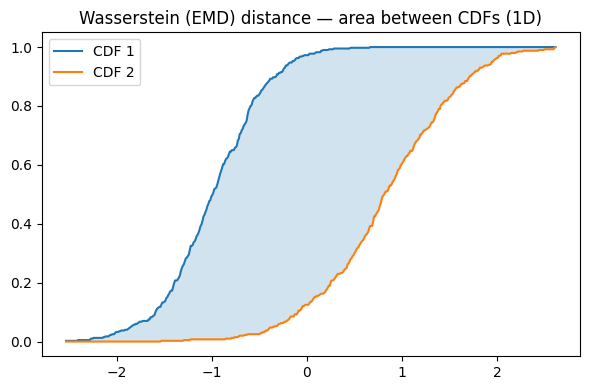

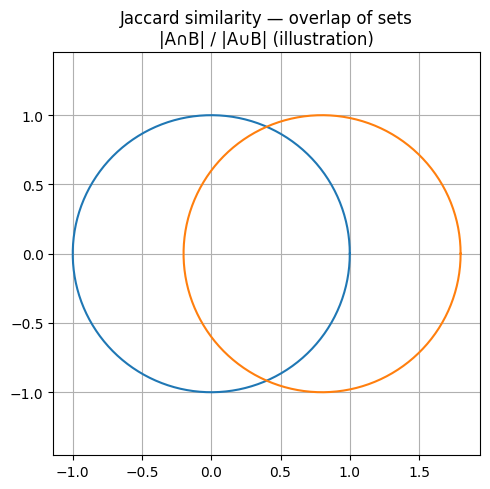

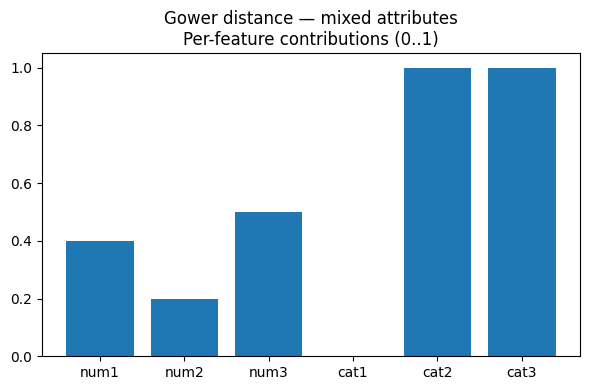

'/projects/illinois/aces/cropsci/ese/CPSC444/pairwise_distance_figures.zip'

In [4]:
# Quick visual graphs for common pairwise distances (spatially linked)

import numpy as np
import matplotlib.pyplot as plt
import math, zipfile, os
from scipy.spatial.distance import cdist

rng = np.random.default_rng(3)
save_dir = "/projects/illinois/aces/cropsci/ese/CPSC444"
os.makedirs(save_dir, exist_ok=True)
saved_files = []

def save_and_show(fig, fname):
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    saved_files.append(path)

# Helper to draw unit "ball" for Minkowski p
def minkowski_ball(p=2.0, r=1.0, n=400):
    t = np.linspace(0, 2*np.pi, n)
    ct, st = np.cos(t), np.sin(t)
    x = r * np.sign(ct) * (np.abs(ct))**(1.0/p)
    y = r * np.sign(st) * (np.abs(st))**(1.0/p)
    return x, y

# ---------- 1) Euclidean (L2) ----------
fig = plt.figure(figsize=(5,5))
x, y = minkowski_ball(p=2, r=1.0)
plt.plot(x, y)
plt.scatter([0, 0.6], [0, 0.8])
plt.title("Euclidean (L2) — unit circle\nStraight-line distance in projected CRS")
plt.axis("equal"); plt.grid(True); plt.tight_layout()
save_and_show(fig, "01_euclidean.png")

# ---------- 2) Manhattan (L1) ----------
fig = plt.figure(figsize=(5,5))
x, y = minkowski_ball(p=1, r=1.0)
plt.plot(x, y)
plt.scatter([0, 0.6], [0, 0.8])
plt.title("Manhattan (L1) — unit diamond\nCity-block/grid movement")
plt.axis("equal"); plt.grid(True); plt.tight_layout()
save_and_show(fig, "02_manhattan.png")

# ---------- 3) Chebyshev (L∞) ----------
fig = plt.figure(figsize=(5,5))
r = 1.0
sq = np.array([[-r,-r],[ r,-r],[ r, r],[-r, r],[-r,-r]])
plt.plot(sq[:,0], sq[:,1])
plt.scatter([0, 0.6], [0, 0.8])
plt.title("Chebyshev (L∞) — unit square\n\"King's move\" on rasters")
plt.axis("equal"); plt.grid(True); plt.tight_layout()
save_and_show(fig, "03_chebyshev.png")

# ---------- 4) Minkowski (Lp, p=1.5) ----------
fig = plt.figure(figsize=(5,5))
x, y = minkowski_ball(p=1.5, r=1.0)
plt.plot(x, y)
plt.scatter([0, 0.6], [0, 0.8])
plt.title("Minkowski (Lp, p=1.5) — unit ball\nBetween L1 and L2")
plt.axis("equal"); plt.grid(True); plt.tight_layout()
save_and_show(fig, "04_minkowski_p1p5.png")

# ---------- 5) Mahalanobis (ellipse from covariance) ----------
fig = plt.figure(figsize=(5,5))
S = np.array([[3.0, 1.2],[1.2, 1.0]])
vals, vecs = np.linalg.eigh(S)
theta = np.linspace(0, 2*np.pi, 400)
circle = np.vstack([np.cos(theta), np.sin(theta)])
A = vecs @ np.diag(np.sqrt(vals)) @ vecs.T
ell = (A @ circle)
plt.plot(ell[0], ell[1])
plt.scatter([0.0, 1.2], [0.0, 0.5])
plt.title("Mahalanobis — unit ellipse\nAccounts for scale & correlation (anisotropy)")
plt.axis("equal"); plt.grid(True); plt.tight_layout()
save_and_show(fig, "05_mahalanobis.png")

# ---------- 6) Anisotropic (rotated–scaled Euclidean) ----------
fig = plt.figure(figsize=(5,5))
ax, ay, ang = 2.0, 0.7, np.deg2rad(30)
R = np.array([[np.cos(ang), -np.sin(ang)],[np.sin(ang), np.cos(ang)]])
ell = R @ np.vstack([ax*np.cos(theta), ay*np.sin(theta)])
plt.plot(ell[0], ell[1])
plt.scatter([0.0, 1.2], [0.0, 0.5])
plt.title("Anisotropic distance — rotated/elliptical ball\nPreferred directions (geology, wind)")
plt.axis("equal"); plt.grid(True); plt.tight_layout()
save_and_show(fig, "06_anisotropic.png")

# ---------- 7) Cosine (angle between vectors) ----------
fig = plt.figure(figsize=(5,5))
a = np.array([1.0, 0.4]); b = np.array([0.2, 1.1])
plt.arrow(0,0,a[0],a[1], length_includes_head=True, head_width=0.08)
plt.arrow(0,0,b[0],b[1], length_includes_head=True, head_width=0.08)
phi_a = np.arctan2(a[1], a[0])
phi_diff = np.arccos(np.clip(np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)), -1, 1))
tt = np.linspace(0, phi_diff, 100)
arc = np.vstack([0.5*np.cos(phi_a+tt), 0.5*np.sin(phi_a+tt)])
plt.plot(arc[0], arc[1])
plt.title("Cosine distance — angle between vectors\nOrientation similarity (direction fields)")
plt.axis("equal"); plt.grid(True); plt.tight_layout()
save_and_show(fig, "07_cosine.png")

# ---------- 8) Geodesic vs chord (great-circle idea on a circle) ----------
fig = plt.figure(figsize=(5,5))
R0 = 1.0
phi1, phi2 = np.deg2rad(40), np.deg2rad(120)
circle = np.vstack([R0*np.cos(theta), R0*np.sin(theta)])
plt.plot(circle[0], circle[1])
p1 = np.array([R0*np.cos(phi1), R0*np.sin(phi1)])
p2 = np.array([R0*np.cos(phi2), R0*np.sin(phi2)])
plt.scatter([p1[0], p2[0]],[p1[1], p2[1]])
plt.plot([p1[0], p2[0]], [p1[1], p2[1]])
tt = np.linspace(phi1, phi2, 200)
arc = np.vstack([R0*np.cos(tt), R0*np.sin(tt)])
plt.plot(arc[0], arc[1])
plt.title("Great-circle (geodesic) vs chord\nUse on sphere/lat-lon (illustration)")
plt.axis("equal"); plt.grid(True); plt.tight_layout()
save_and_show(fig, "08_geodesic_vs_chord.png")

# ---------- 9) Network / shortest-path distance ----------
fig = plt.figure(figsize=(6,5))
pts = [(i,j) for i in range(4) for j in range(3)]
edges = []
for (i,j) in pts:
    if i<3: edges.append(((i,j),(i+1,j)))
    if j<2: edges.append(((i,j),(i,j+1)))
from collections import deque
adj = {p:[] for p in pts}
for u,v in edges:
    adj[u].append(v); adj[v].append(u)
start, goal = (0,0), (3,2)
prev = {start: None}
dq = deque([start])
while dq:
    u = dq.popleft()
    if u==goal: break
    for w in adj[u]:
        if w not in prev:
            prev[w]=u; dq.append(w)
path = []
u = goal
while u is not None:
    path.append(u); u=prev.get(u,None)
path = path[::-1]
for (u,v) in edges:
    plt.plot([u[0], v[0]], [u[1], v[1]])
xs, ys = zip(*pts)
plt.scatter(xs, ys)
px, py = zip(*path)
plt.plot(px, py, linewidth=3)
plt.title("Network (shortest-path) distance\nRoad/river/transit graphs")
plt.axis("equal"); plt.grid(True); plt.tight_layout()
save_and_show(fig, "09_network_shortest_path.png")

# ---------- 10) Gaussian vs Exponential kernel weights vs distance ----------
fig = plt.figure(figsize=(6,4))
d = np.linspace(0, 5, 200)
sigma = 1.2; phi = 1.2
w_gauss = np.exp(-(d**2)/(2*sigma**2))
w_exp   = np.exp(-d/phi)
plt.plot(d, w_gauss, label="Gaussian kernel")
plt.plot(d, w_exp, label="Exponential kernel")
plt.legend()
plt.xlabel("Distance"); plt.ylabel("Weight")
plt.title("Distance-decay kernels → spatial weights")
plt.tight_layout()
save_and_show(fig, "10_distance_kernels.png")

# ---------- 11) DTW (toy): two time series and warping path on cost matrix ----------
def dtw_path(a, b):
    A, B = len(a), len(b)
    D = np.full((A+1,B+1), np.inf)
    D[0,0]=0
    for i in range(1,A+1):
        for j in range(1,B+1):
            cost = (a[i-1]-b[j-1])**2
            D[i,j] = cost + min(D[i-1,j], D[i,j-1], D[i-1,j-1])
    i, j = A, B
    path = []
    while i>0 and j>0:
        path.append((i-1,j-1))
        step = np.argmin([D[i-1,j], D[i,j-1], D[i-1,j-1]])
        if step==0: i-=1
        elif step==1: j-=1
        else: i-=1; j-=1
    path.reverse()
    return D[1:,1:], path

a = np.sin(np.linspace(0, 2*np.pi, 50))
b = np.sin(np.linspace(0, 2*np.pi, 35) + 0.4)
Dmat, path = dtw_path(a, b)
fig = plt.figure(figsize=(6,5))
plt.imshow(Dmat, origin="lower", aspect="auto")
px, py = zip(*path)
plt.plot(py, px)
plt.title("DTW distance — warping path on cost matrix\n(trajectories / movement)")
plt.tight_layout()
save_and_show(fig, "11_dtw.png")

# ---------- 12) Hausdorff (two point sets; farthest nearest-neighbor) ----------
fig = plt.figure(figsize=(5,5))
A = np.array([[0.1,0.2],[0.3,0.8],[0.8,0.2],[0.9,0.9]])
B = np.array([[0.2,0.2],[0.4,0.7],[0.7,0.3]])
plt.scatter(A[:,0], A[:,1])
plt.scatter(B[:,0], B[:,1], marker="x")
Ddir = cdist(A,B)
mins = Ddir.min(axis=1)
idx = np.argmax(mins)
j = np.argmin(Ddir[idx])
plt.plot([A[idx,0], B[j,0]],[A[idx,1], B[j,1]])
plt.title("Hausdorff distance (A→B): farthest nearest-neighbor\n(Shape/set similarity)")
plt.axis("equal"); plt.grid(True); plt.tight_layout()
save_and_show(fig, "12_hausdorff.png")

# ---------- 13) Wasserstein / Earth Mover's (1D illustration) ----------
fig = plt.figure(figsize=(6,4))
x1 = rng.normal(-1.0, 0.5, 400)
x2 = rng.normal( 0.8, 0.7, 400)
xs = np.linspace(min(x1.min(),x2.min()), max(x1.max(),x2.max()), 500)
F1 = np.searchsorted(np.sort(x1), xs, side="right")/len(x1)
F2 = np.searchsorted(np.sort(x2), xs, side="right")/len(x2)
plt.plot(xs, F1, label="CDF 1")
plt.plot(xs, F2, label="CDF 2")
plt.fill_between(xs, F1, F2, alpha=0.2)
plt.title("Wasserstein (EMD) distance — area between CDFs (1D)")
plt.legend(); plt.tight_layout()
save_and_show(fig, "13_wasserstein.png")

# ---------- 14) Jaccard (set overlap illustration) ----------
fig = plt.figure(figsize=(5,5))
theta = np.linspace(0, 2*np.pi, 400)
c1 = np.vstack([np.cos(theta), np.sin(theta)])
c2 = np.vstack([np.cos(theta)+0.8, np.sin(theta)])
plt.plot(c1[0], c1[1]); plt.plot(c2[0], c2[1])
plt.title("Jaccard similarity — overlap of sets\n|A∩B| / |A∪B| (illustration)")
plt.axis("equal"); plt.grid(True); plt.tight_layout()
save_and_show(fig, "14_jaccard.png")

# ---------- 15) Gower (mixed attributes; per-feature contributions) ----------
fig = plt.figure(figsize=(6,4))
num1 = np.array([0.2, 0.7, 0.4])
num2 = np.array([0.6, 0.5, 0.9])
cat1 = np.array([1, 0, 1])
cat2 = np.array([1, 1, 0])
num_diff = np.abs(num1 - num2)
cat_diff = (cat1 != cat2).astype(float)
labels = [f"num{i+1}" for i in range(len(num1))] + [f"cat{i+1}" for i in range(len(cat1))]
vals = np.concatenate([num_diff, cat_diff])
plt.bar(np.arange(len(vals)), vals, tick_label=labels)
plt.ylim(0,1.05)
plt.title("Gower distance — mixed attributes\nPer-feature contributions (0..1)")
plt.tight_layout()
save_and_show(fig, "15_gower.png")

# Create a ZIP archive of all saved files
zip_path = os.path.join(save_dir, "pairwise_distance_figures.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for f in saved_files:
        zf.write(f, arcname=os.path.basename(f))

zip_path
